In [1]:
%run radarSingalProcessingHelper.ipynb 

import os
import re
import shutil
import tempfile

import os
import re
import shutil
import tempfile

def filter_scan_files(folder_path):
    """
    Scans a folder for .dat files matching 'scan_i_ref_j.dat' and 'scan_i_rx_j.dat' patterns.
    Returns two lists, each containing filenames with the smallest 'j' for each 'i'.

    Args:
        folder_path (str): The full path to the directory to scan.

    Returns:
        tuple: A tuple containing two sorted lists of filenames:
               (ref_files, rx_files).
               - ref_files: For each scan index 'i', only the 'ref' file with the
                            minimum index 'j' is included.
               - rx_files: For each scan index 'i', only the 'rx' file with the
                           minimum index 'j' is included.
        None: If the provided path is not a valid directory.
    """
    if not os.path.isdir(folder_path):
        print(f"Error: Directory not found at '{folder_path}'")
        return None, None

    # Regex patterns for both file types
    pattern_ref = re.compile(r"scan_(\d+)_ref_(\d+)\.dat")
    pattern_rx = re.compile(r"scan_(\d+)_rx_(\d+)\.dat")
    
    # Dictionaries to hold the minimum 'j' file for each 'i' for both types
    min_ref_map = {}
    min_rx_map = {}

    # Iterate over all files in the given directory
    for filename in os.listdir(folder_path):
        match_ref = pattern_ref.match(filename)
        match_rx = pattern_rx.match(filename)
        
        # Check if the filename matches the 'ref' pattern
        if match_ref:
            i = int(match_ref.group(1))
            j = int(match_ref.group(2))

            if i not in min_ref_map or j < min_ref_map[i]['j']:
                min_ref_map[i] = {'j': j, 'filename': filename}
        
        # Else, check if the filename matches the 'rx' pattern
        elif match_rx:
            i = int(match_rx.group(1))
            j = int(match_rx.group(2))

            if i not in min_rx_map or j < min_rx_map[i]['j']:
                min_rx_map[i] = {'j': j, 'filename': filename}

    # --- Process REF files ---
    # Sort the dictionary items by the scan index 'i' (the key)
    sorted_ref_items = sorted(min_ref_map.items())
    # Extract just the filenames
    result_ref_filenames = [value['filename'] for key, value in sorted_ref_items]
    
    # --- Process RX files ---
    # Sort the dictionary items by the scan index 'i' (the key)
    sorted_rx_items = sorted(min_rx_map.items())
    # Extract just the filenames
    result_rx_filenames = [value['filename'] for key, value in sorted_rx_items]
    
    return result_ref_filenames, result_rx_filenames

def converTodB(input_arr):
    return 10 * np.log10(np.abs(input_arr) + 1e-9)

plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 10, 'axes.titlesize': 12,
    'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 12,
    'figure.dpi': 300, 'savefig.dpi': 300,
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
})

/tmp/ipykernel_22922/3284984068.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


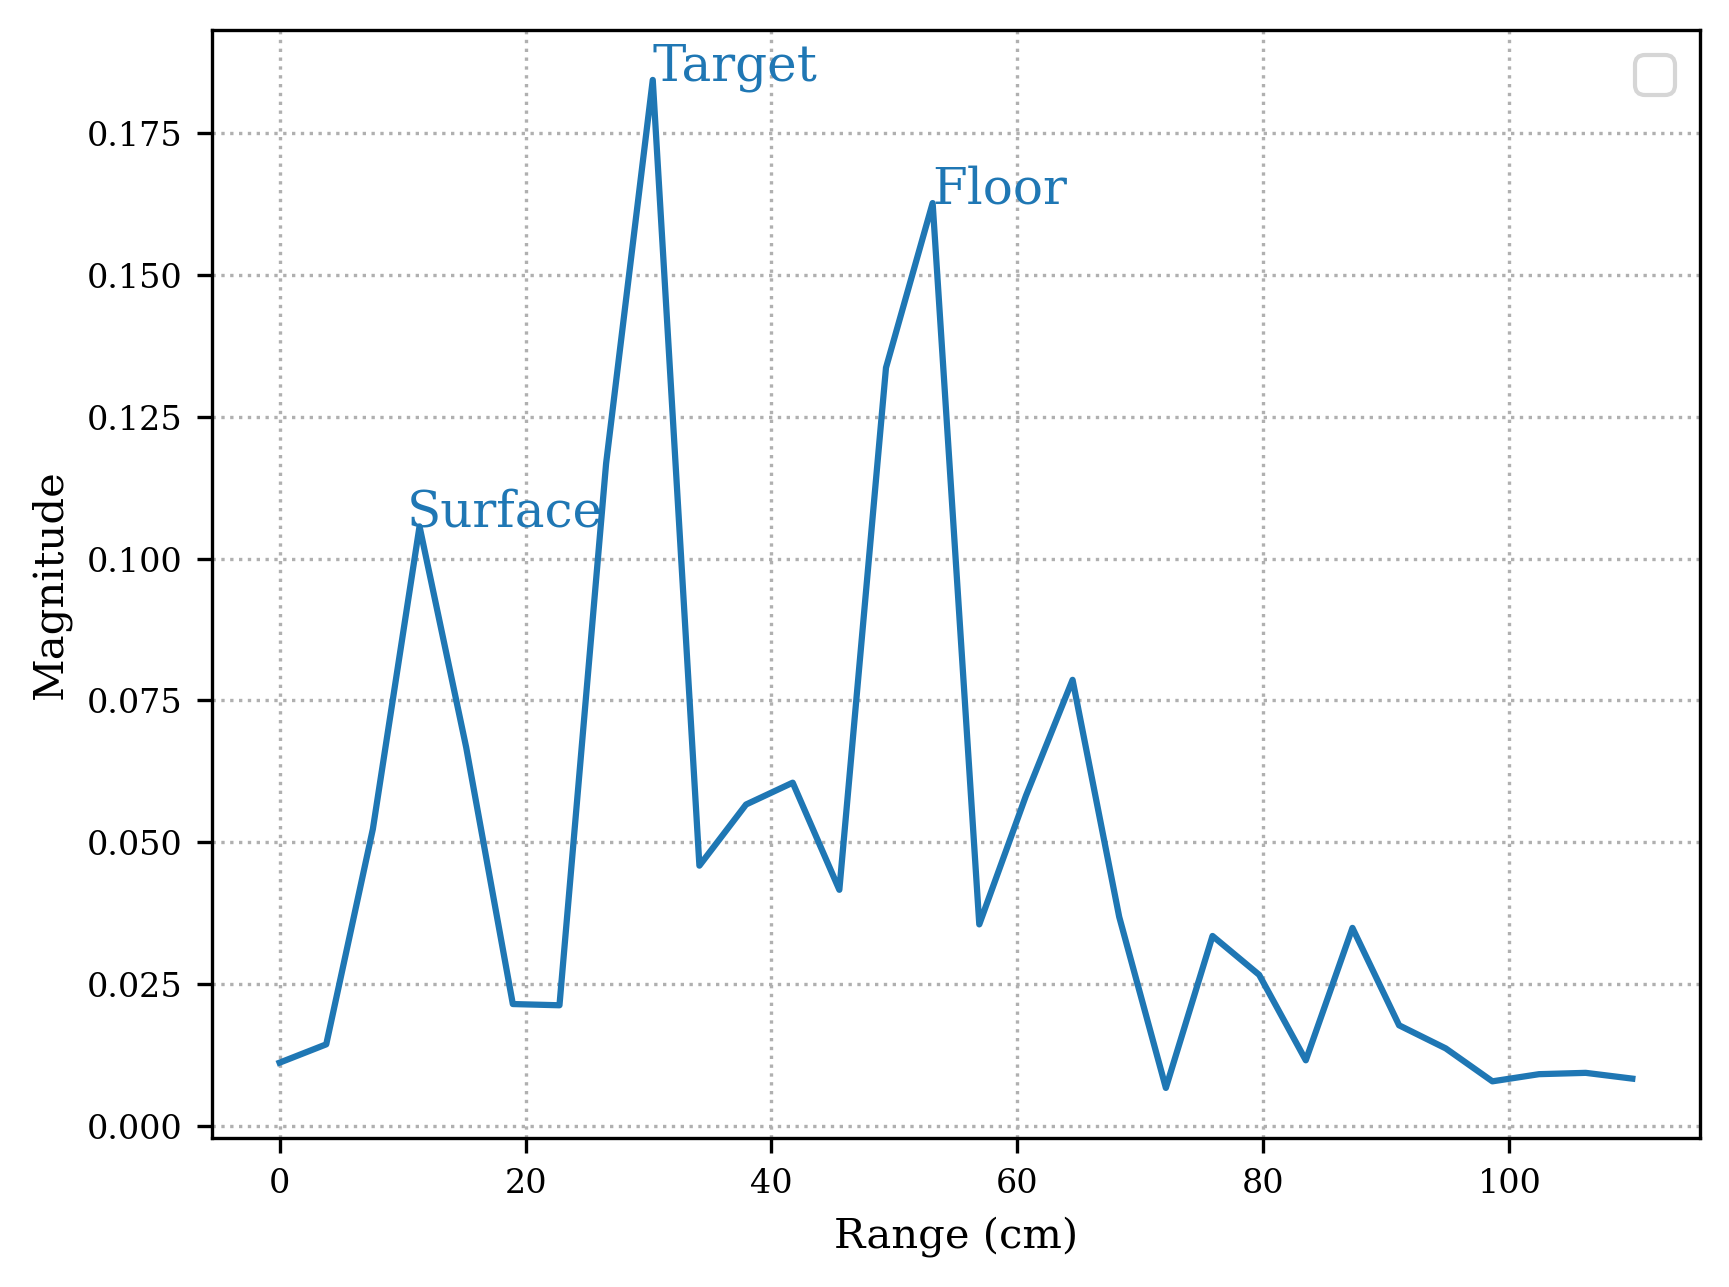

In [2]:
SAMPLING_RATE = 5e6    # 5 MHz
CHIRP_BANDWIDTH = 2e6  # 1 MHz
burst_len = 1024
num_steps = 128
supposed_size = burst_len*num_steps
cut_off = 2.4e6
transition_width = 1e6

c = 1.34e8  # Speed of light
max_range = c / (2 * SAMPLING_RATE)
range_axis = np.linspace(0, 110, 30)

i = 8
folder_path = "/home/hui/bladerf_sfcw_radar/data/GPR_ex/line_" + str(i) + "/"
ref_scan_file_list, rx_scan_file_list = filter_scan_files(folder_path)
j = 8
fileName_ref = folder_path + ref_scan_file_list[j]
fileName_rx = folder_path + rx_scan_file_list[j]
rx_samples_reshaped, ref_samples_reshaped, rx_samples, ref_samples = process_raw_samples(fileName_rx, fileName_ref, burst_len, num_steps, transition_width, cut_off)

# --- Generate the A-scan using the function ---
ascan_profile, calibrated_channel_response, echo_response = generate_ascan_from_lfm(
    echo_signals=rx_samples,
    reference_signals=ref_samples,
    num_steps=num_steps,
    step_length=burst_len,
    chirp_bandwidth=CHIRP_BANDWIDTH,
    sampling_rate_hz=SAMPLING_RATE
)

ascan_mag = np.abs(ascan_profile[10:40])
plt.plot(range_axis,ascan_mag)
peak_index = find_index(ascan_mag,-1)
peak_range = range_axis[peak_index]
peak_mag = ascan_mag[peak_index]
plt.text(peak_range, peak_mag, "Target", fontsize=12, color=plt.gca().lines[-1].get_color())

peak_index = find_index(ascan_mag,-2)
peak_range = range_axis[peak_index]
peak_mag = ascan_mag[peak_index]
plt.text(peak_range, peak_mag, "Floor", fontsize=12, color=plt.gca().lines[-1].get_color())

peak_index = find_index(ascan_mag,-5)
peak_range = range_axis[peak_index]
peak_mag = ascan_mag[peak_index]
plt.text(peak_range-1, peak_mag, "Surface", fontsize=12, color=plt.gca().lines[-1].get_color())

# --- 5. Finalize and Save Figure ---
plt.xlabel('Range (cm)')
plt.ylabel('Magnitude')
plt.grid(True, linestyle=':')
#plt.xlim(0, max_range/2)
plt.legend()

plt.savefig("GPR_a.eps", bbox_inches='tight')
plt.show()

In [3]:
b_scan_list = []
for i in range(14):
    folder_path = "/home/hui/bladerf_sfcw_radar/data/GPR_ex/line_" + str(i) + "/"
    ref_scan_file_list, rx_scan_file_list = filter_scan_files(folder_path)
    a_scan_list = []
    for j in range(14):
        fileName_ref = folder_path + ref_scan_file_list[j]
        fileName_rx = folder_path + rx_scan_file_list[j]
        rx_samples_reshaped, ref_samples_reshaped, rx_samples, ref_samples = process_raw_samples(fileName_rx, fileName_ref, burst_len, num_steps, transition_width, cut_off)
        
        # --- Generate the A-scan using the function ---
        ascan_profile, calibrated_channel_response, echo_response = generate_ascan_from_lfm(
            echo_signals=rx_samples,
            reference_signals=ref_samples,
            num_steps=num_steps,
            step_length=burst_len,
            chirp_bandwidth=CHIRP_BANDWIDTH,
            sampling_rate_hz=SAMPLING_RATE
        )
        a_scan_list.append(ascan_profile)
        b_scan = np.stack(a_scan_list, axis=0)
    b_scan_list.append(b_scan)
c_scan = np.stack(b_scan_list,axis=0)

/tmp/ipykernel_22922/2966348773.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


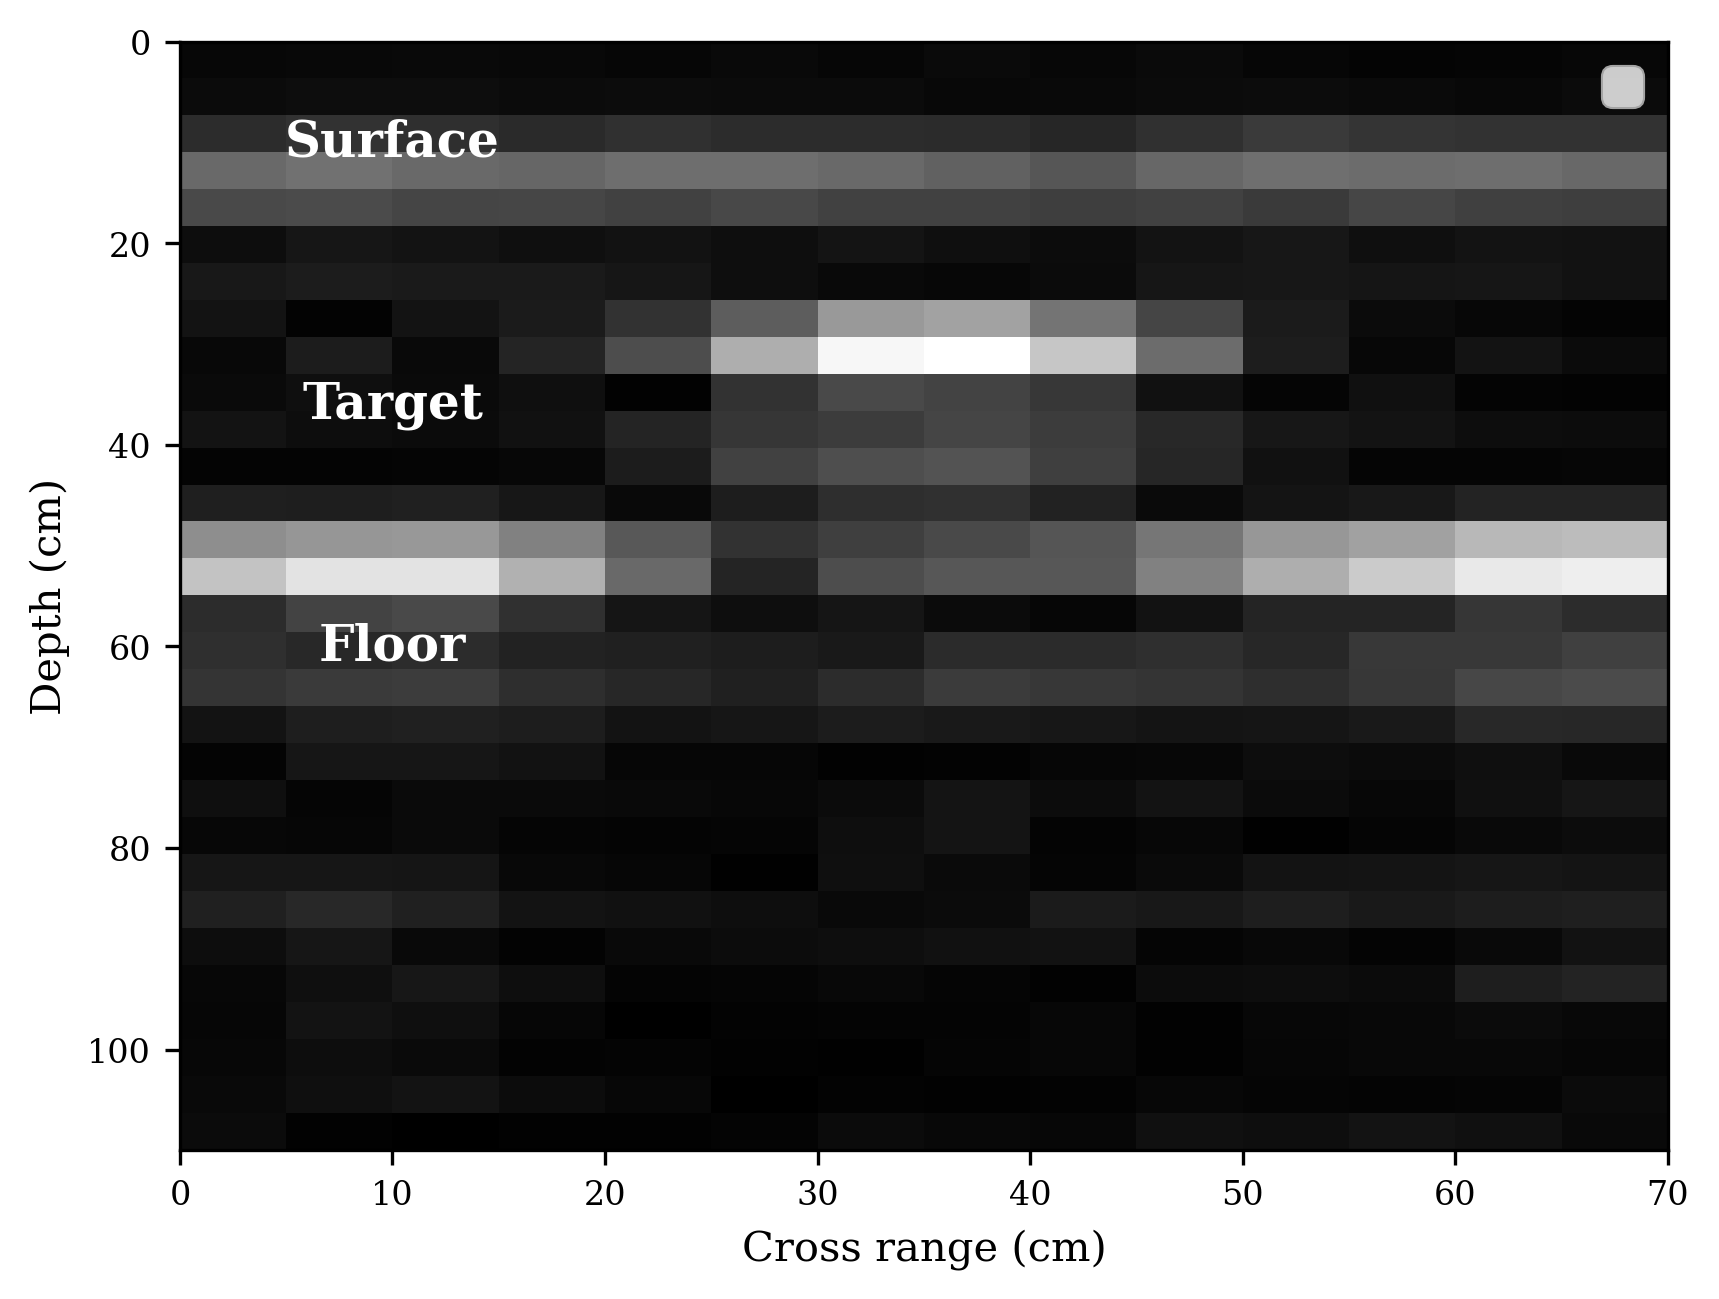

In [4]:
# for index in range(14):
#     plt.figure()
#     plt.imshow(converTodB(b_scan_list[index]))
plt.figure()
b_scan_mag = np.abs(b_scan_list[9])[:,10:40]
plt.imshow(np.transpose(b_scan_mag),aspect='auto', cmap='grey', origin='upper', extent=[0, 14*5, 110, 0])

plt.text(10, 60, 
         'Floor', 
         color='white', 
         fontsize=12, 
         fontweight='bold',
         ha='center', # Horizontal alignment
         va='center') # Vertical alignment

plt.text(10, 36, 
         'Target', 
         color='white', 
         fontsize=12, 
         fontweight='bold',
         ha='center', # Horizontal alignment
         va='center') # Vertical alignment

plt.text(10, 10, 
         'Surface', 
         color='white', 
         fontsize=12, 
         fontweight='bold',
         ha='center', # Horizontal alignment
         va='center') # Vertical alignment

# --- 5. Finalize and Save Figure ---
plt.ylabel('Depth (cm)')
plt.xlabel('Cross range (cm)')
#plt.grid(True, linestyle=':')
#plt.ylim(0, 0.5)
plt.legend()

plt.savefig("GPR_b.png", bbox_inches='tight')
plt.show()

/tmp/ipykernel_22922/3543831000.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


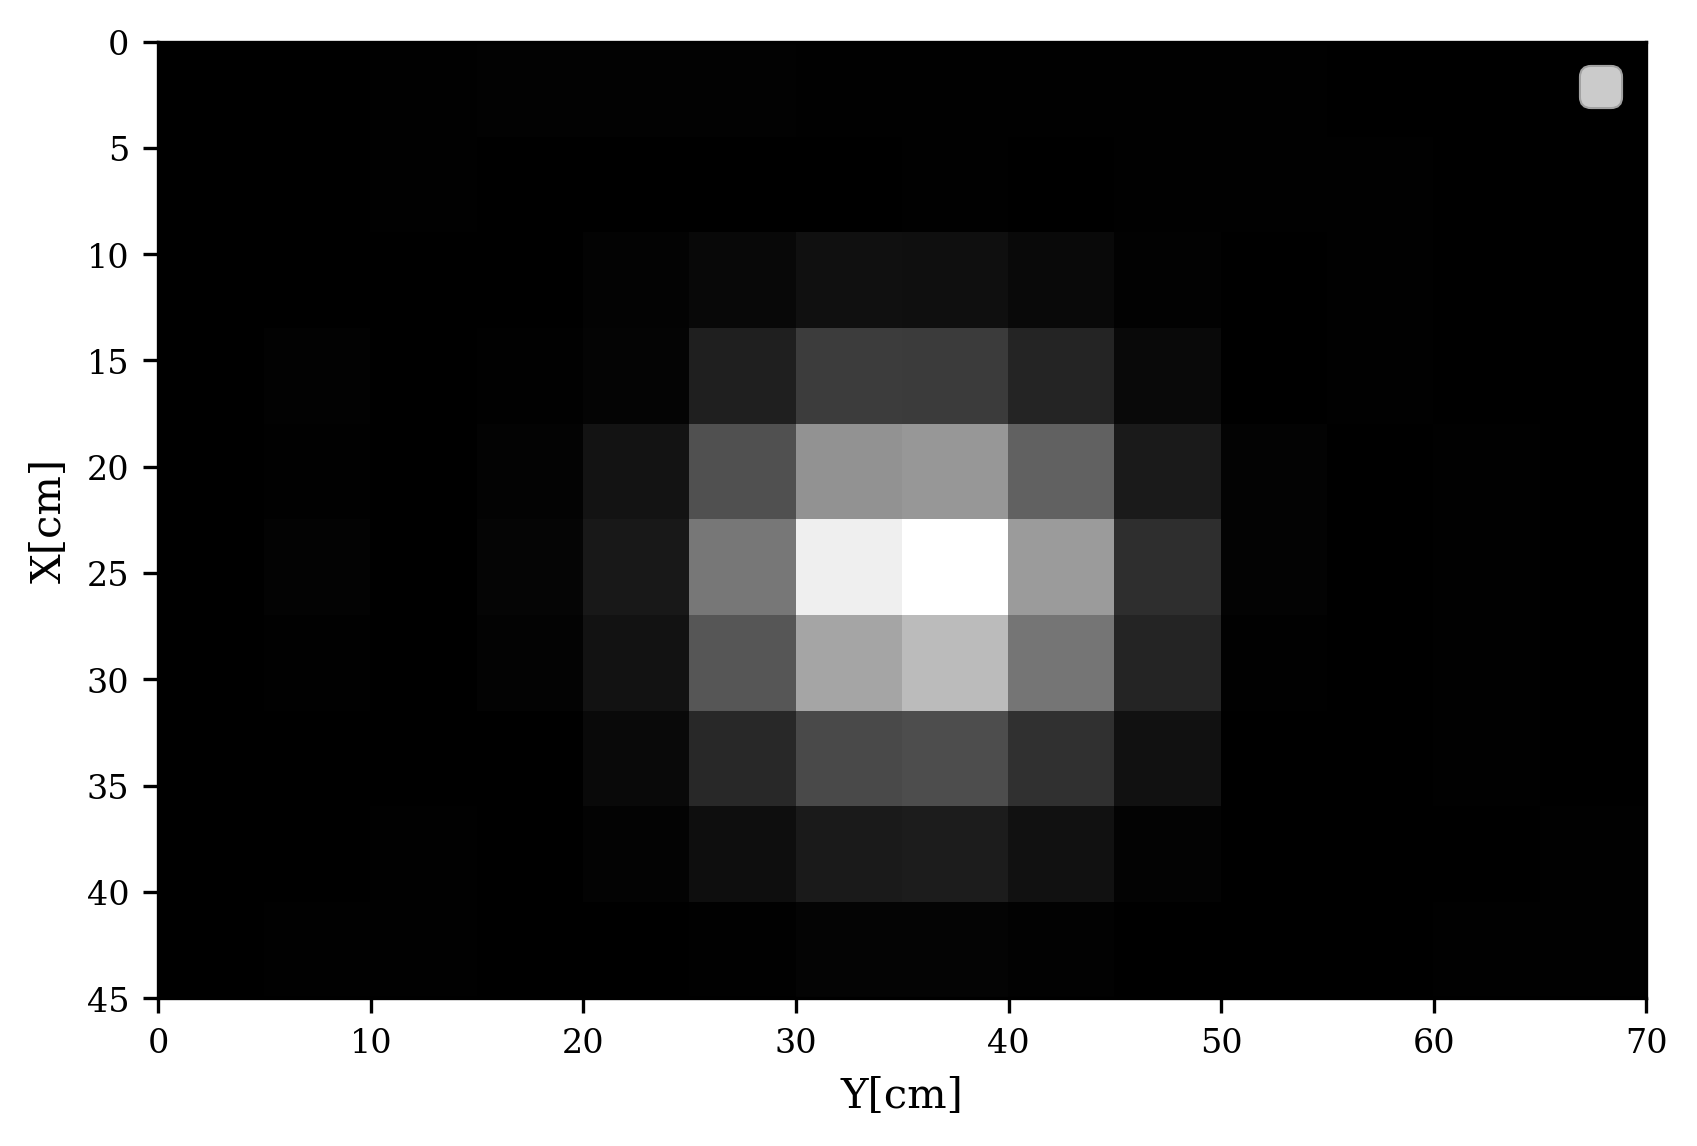

In [5]:
index = 18
plt.imshow(np.abs(c_scan[4:14,:,index]**2),cmap="grey", extent=[0, 14*5, 45, 0])#,vmin=np.max(np.abs(c_scan)**2)/4,vmax=np.max(np.abs(c_scan)**2))
# --- 5. Finalize and Save Figure ---
plt.ylabel('X[cm]')
plt.xlabel('Y[cm]')
#plt.grid(True, linestyle=':')
#plt.ylim(0, 0.5)
plt.legend()
plt.savefig("GPR_c.png", bbox_inches='tight')
plt.show()

In [198]:
c_scan.shape

(14, 14, 128)

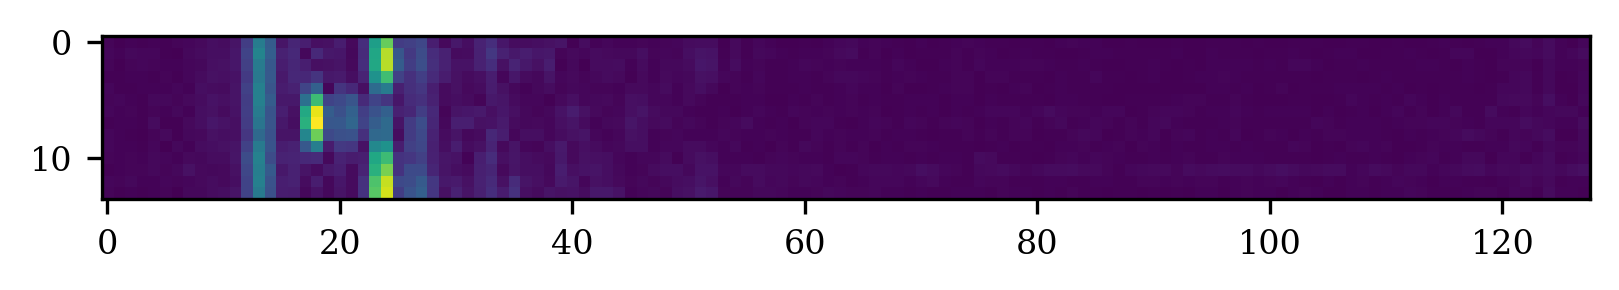

In [43]:
plt.imshow(np.abs(b_scan))

In [41]:
import numpy as np
import matplotlib.pyplot as plt
def processSignals(ref, echo, burst_len, num_steps):
    signal_ratio = echo*np.conjugate(ref);
    signal_ratio_reshaped = np.reshape(signal_ratio,[-1,burst_len])
    freq_response = np.mean(signal_ratio_reshaped, axis=1)
    s = freq_response * np.hamming(num_steps)
    s = np.fft.ifft(s)
    return freq_response, s

def B_scan(dir, prefix, burst_len, num_steps):
    supposed_size = burst_len*num_steps
    s_list = []
    for i in range(14):
        #print(i)
        fileName_rx = dir + prefix + '_rx_' + str(i) + '.dat'
        fileName_ref = dir + prefix + '_ref_' + str(i) + '.dat'
        
        ref_samples = np.fromfile(fileName_ref, np.complex64)
        N = supposed_size - ref_samples.size
        #print(ref_samples.size,N)
        if N>=0:
            ref_samples = np.pad(ref_samples,(0,N),'constant')
        else:
            ref_samples = ref_samples[0:supposed_size]
        
        rx_samples = np.fromfile(fileName_rx, np.complex64)  
        N = supposed_size - rx_samples.size
        #print(rx_samples.size,N)
        if N>=0:
            rx_samples = np.pad(rx_samples,(0,N),'constant')
        else:
            rx_samples = rx_samples[0:supposed_size]
        
        f,s = processSignals(ref_samples, rx_samples, burst_len, num_steps)
        s_list.append(s)
    return np.stack(s_list, axis=0)   

(14, 128)
(14, 128)
(14, 128)
(14, 128)
(14, 128)
(14, 128)
(14, 128)
(14, 128)


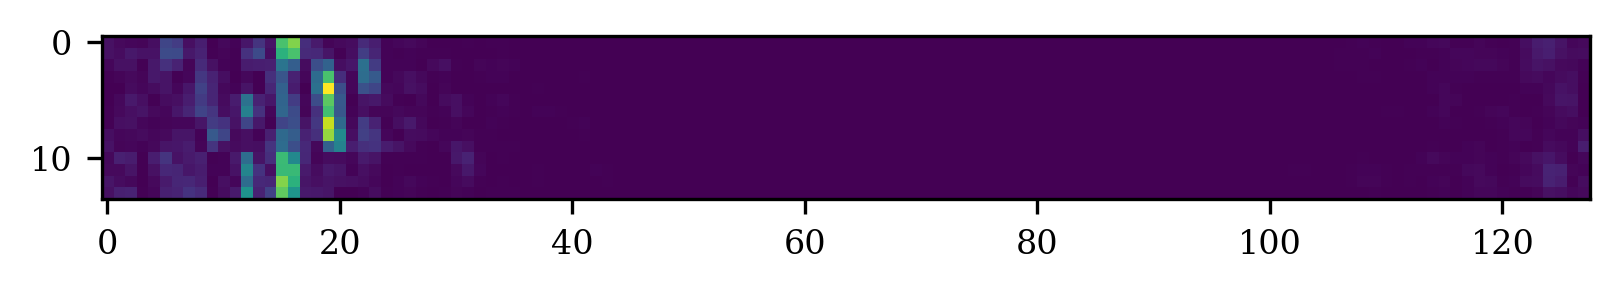

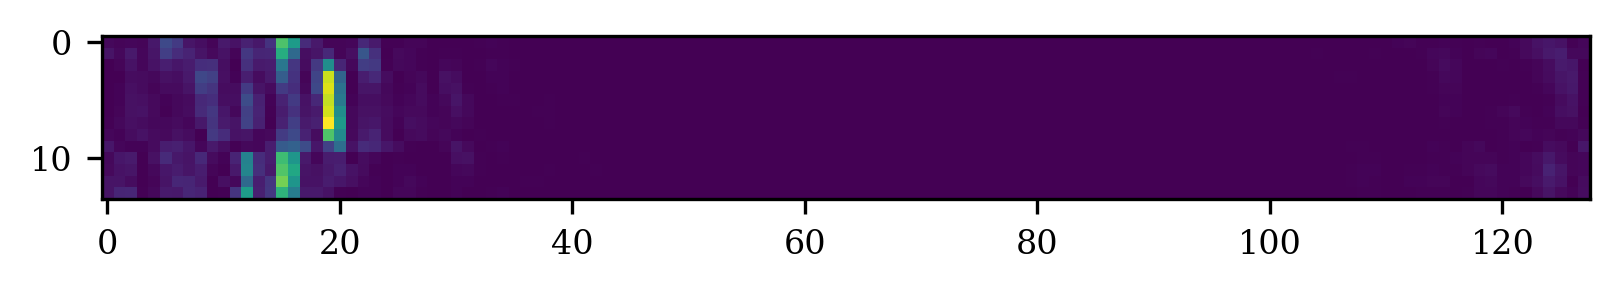

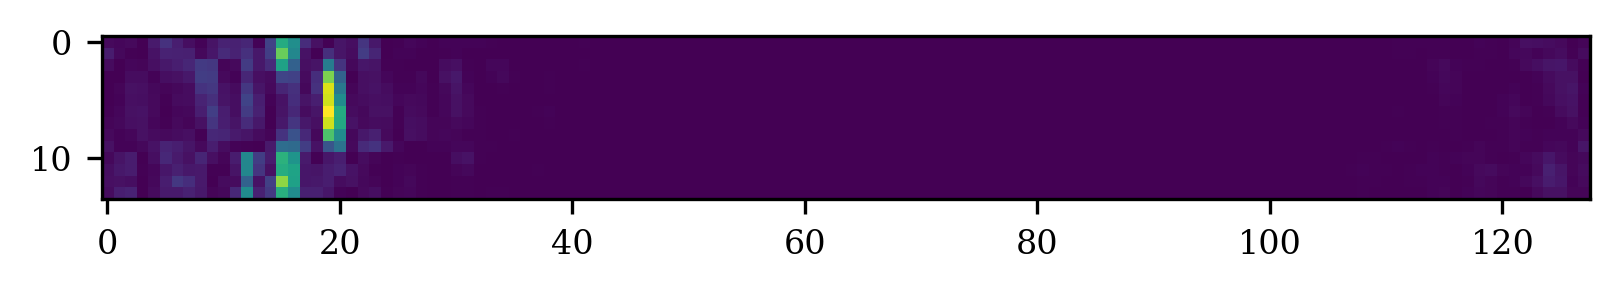

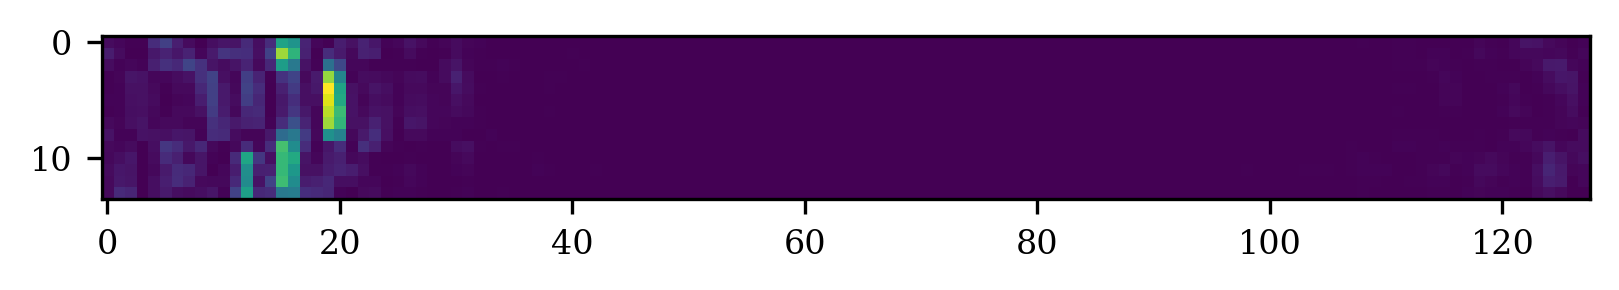

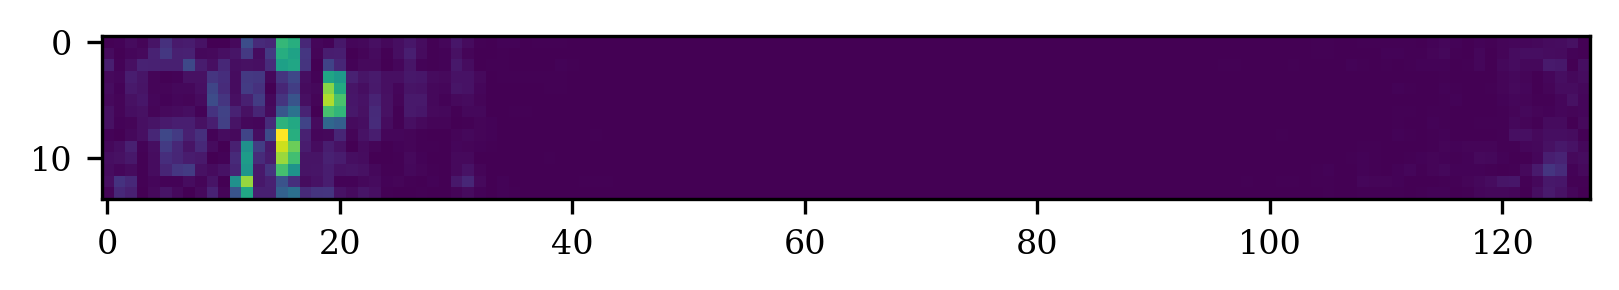

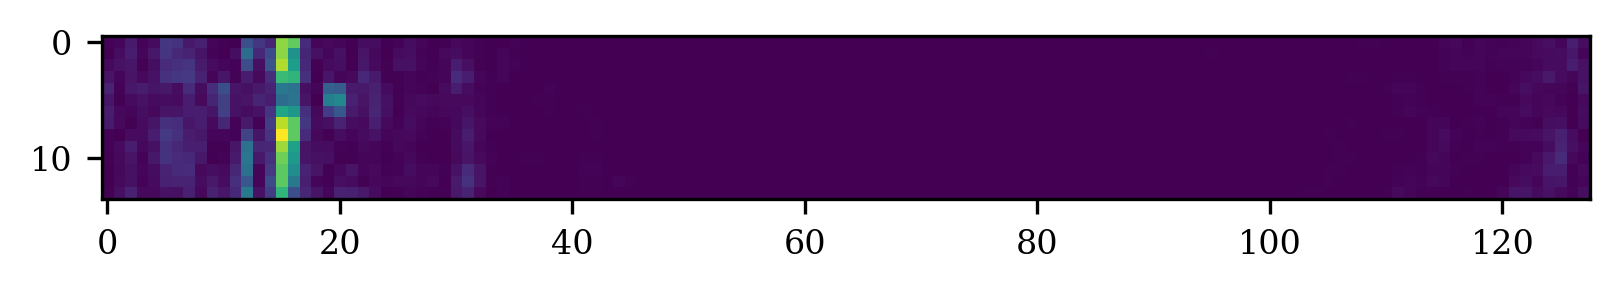

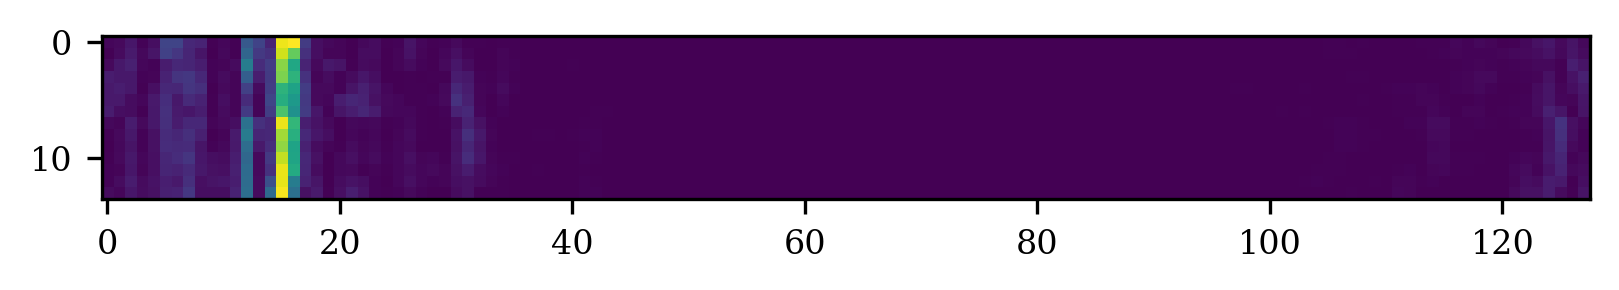

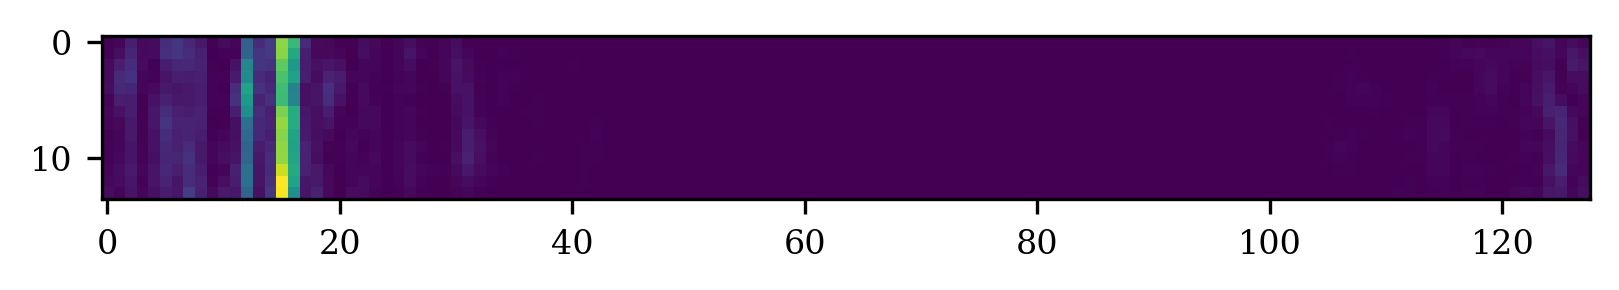

In [42]:
burst_len = 4096
num_steps = 128
supposed_size = burst_len*num_steps
b_scan_list = []
for dir_index in range(1,9):
    dir = '/home/hui/gpr_dataset/squarePlate/line' + str(dir_index)+'/'
    prefix = 'scan_raw'
    b_scan = B_scan(dir,prefix,burst_len,num_steps)
    plt.figure()
    plt.imshow(np.abs(b_scan)**2)
    print(b_scan.shape)
    b_scan_list.append(b_scan)

/tmp/ipykernel_931271/739599650.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


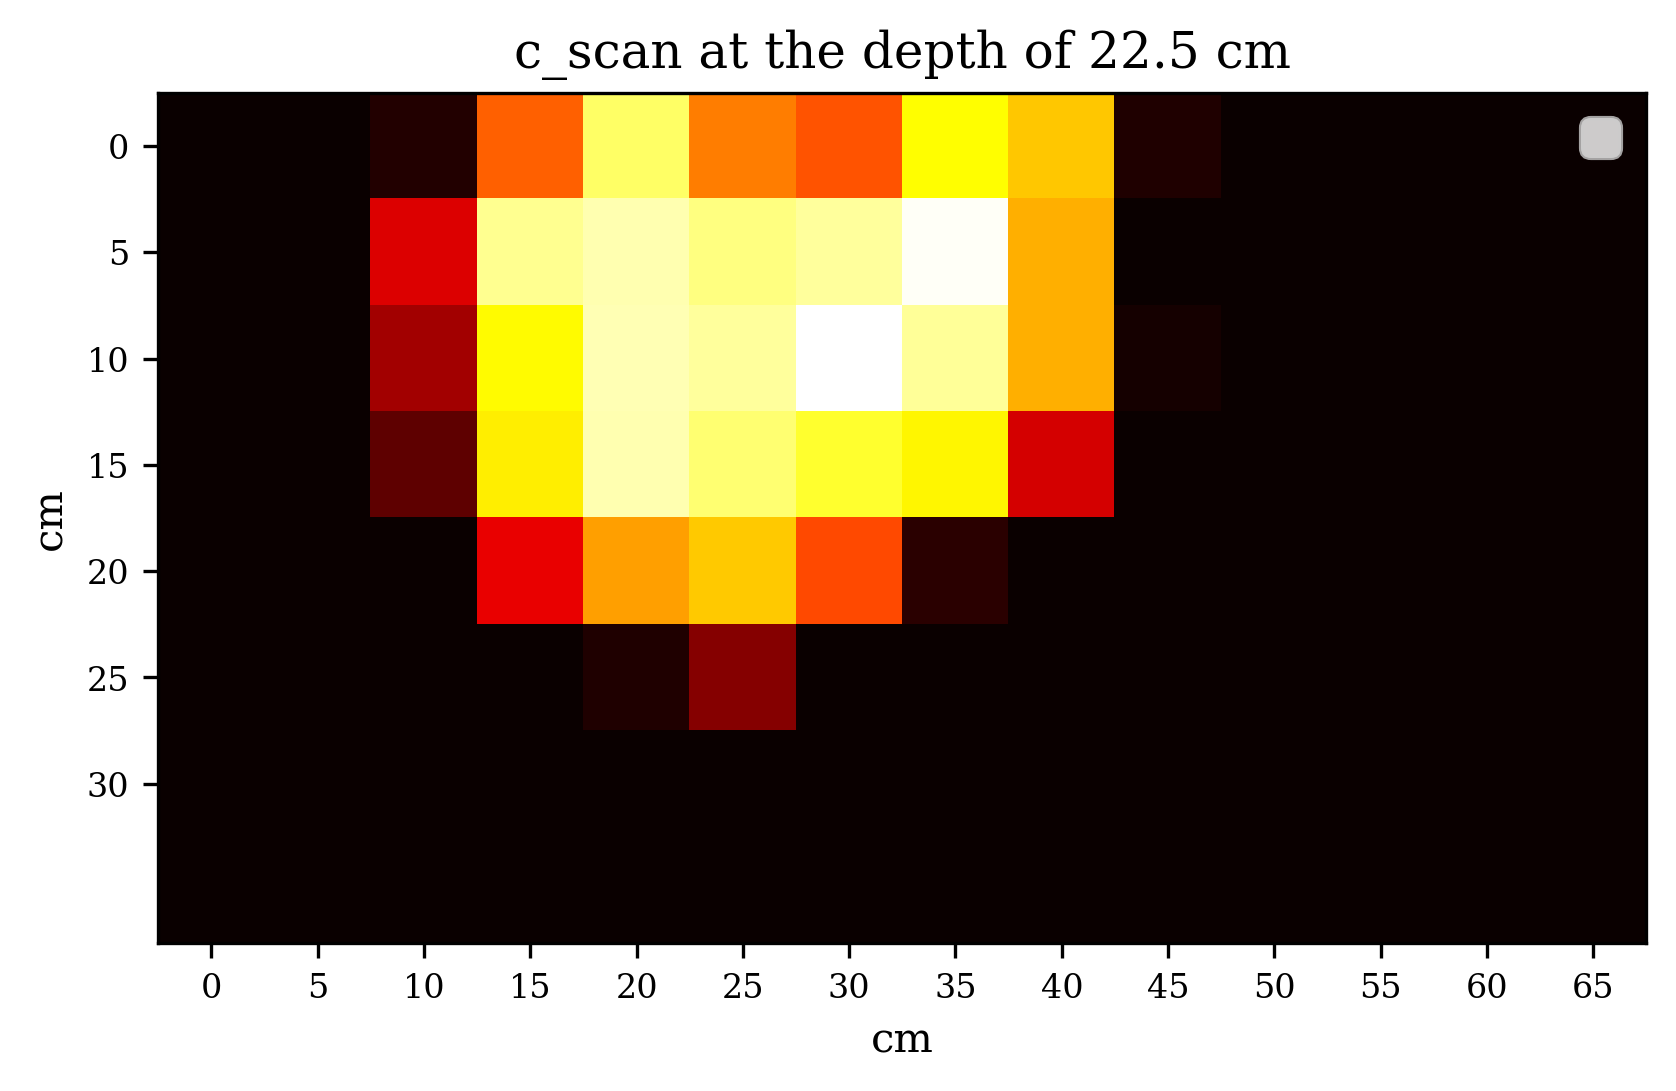

In [43]:
c_scan = np.stack(b_scan_list,axis=0)
index = 19
plt.imshow(np.abs(c_scan[:,:,index]**2),cmap="hot",vmin=np.max(np.abs(c_scan)**2)/4,vmax=np.max(np.abs(c_scan)**2))
plt.xlabel('cm')
plt.xticks(np.arange(0, 14, step=1), labels=[str(i*5) for i in range(14)])
plt.ylabel('cm')
plt.yticks(np.arange(0, 7, step=1), labels=[str(i*5) for i in range(7)])
depth = (index - 16)*7.5
plt.title("c_scan at the depth of " + str(depth) + " cm")
plt.legend()
plt.savefig('c_scan')

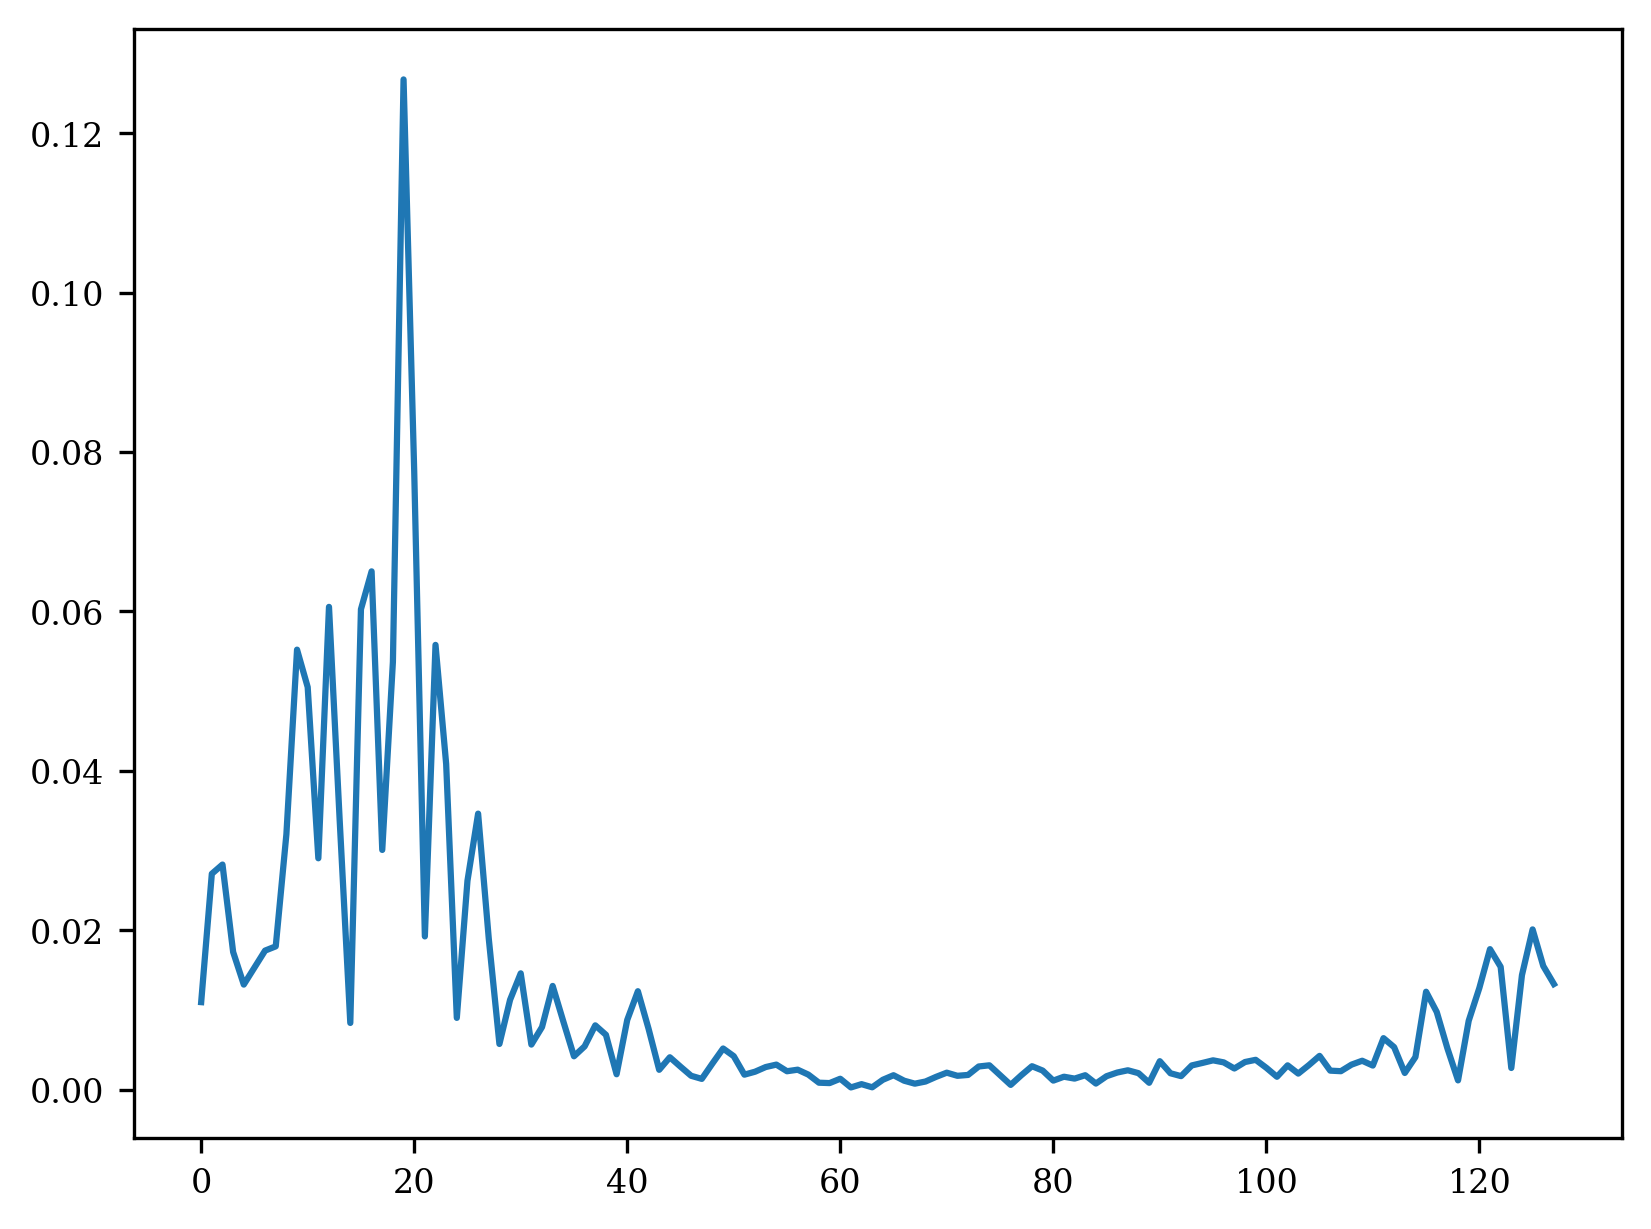

In [32]:
normalized_magnitude = np.abs(b_scan_list[0][7])
ascan_db = 10 * np.log10(normalized_magnitude + 1e-9)
plt.plot(normalized_magnitude)

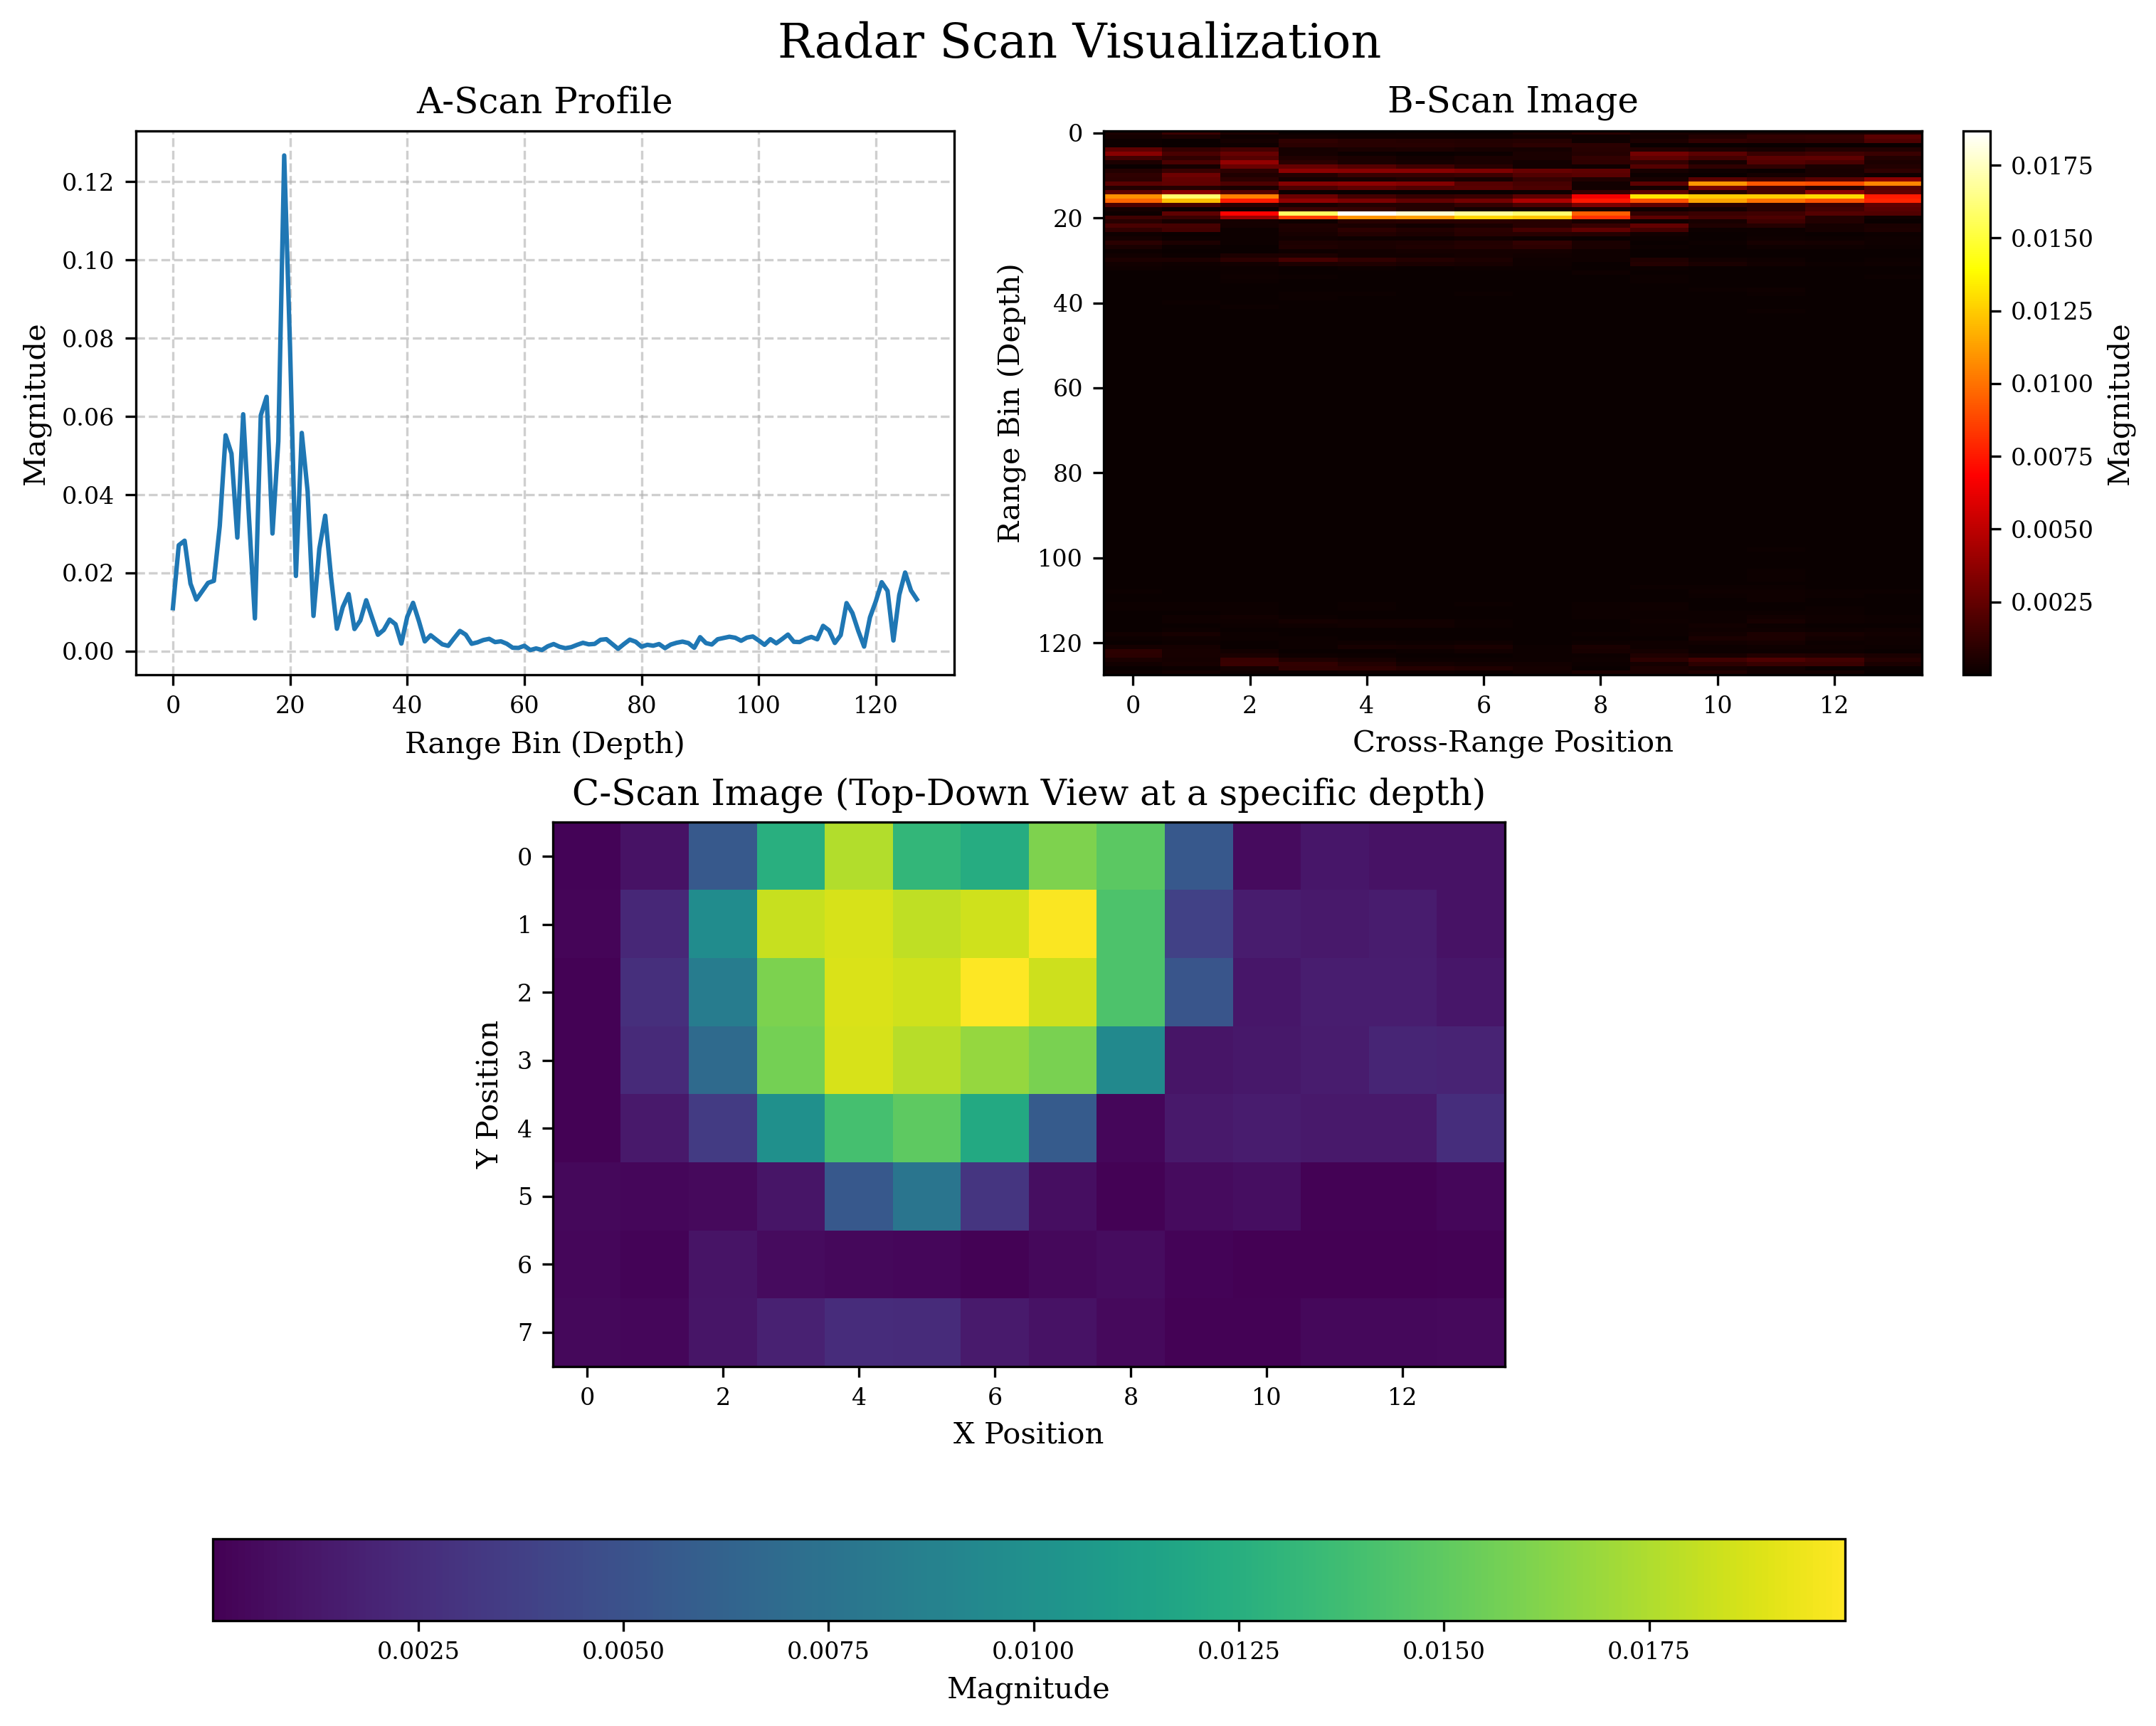

In [51]:
index = 19
plot_radar_scans(normalized_magnitude, np.abs(b_scan_list[3])**2, np.abs(c_scan[:,:,index])**2)

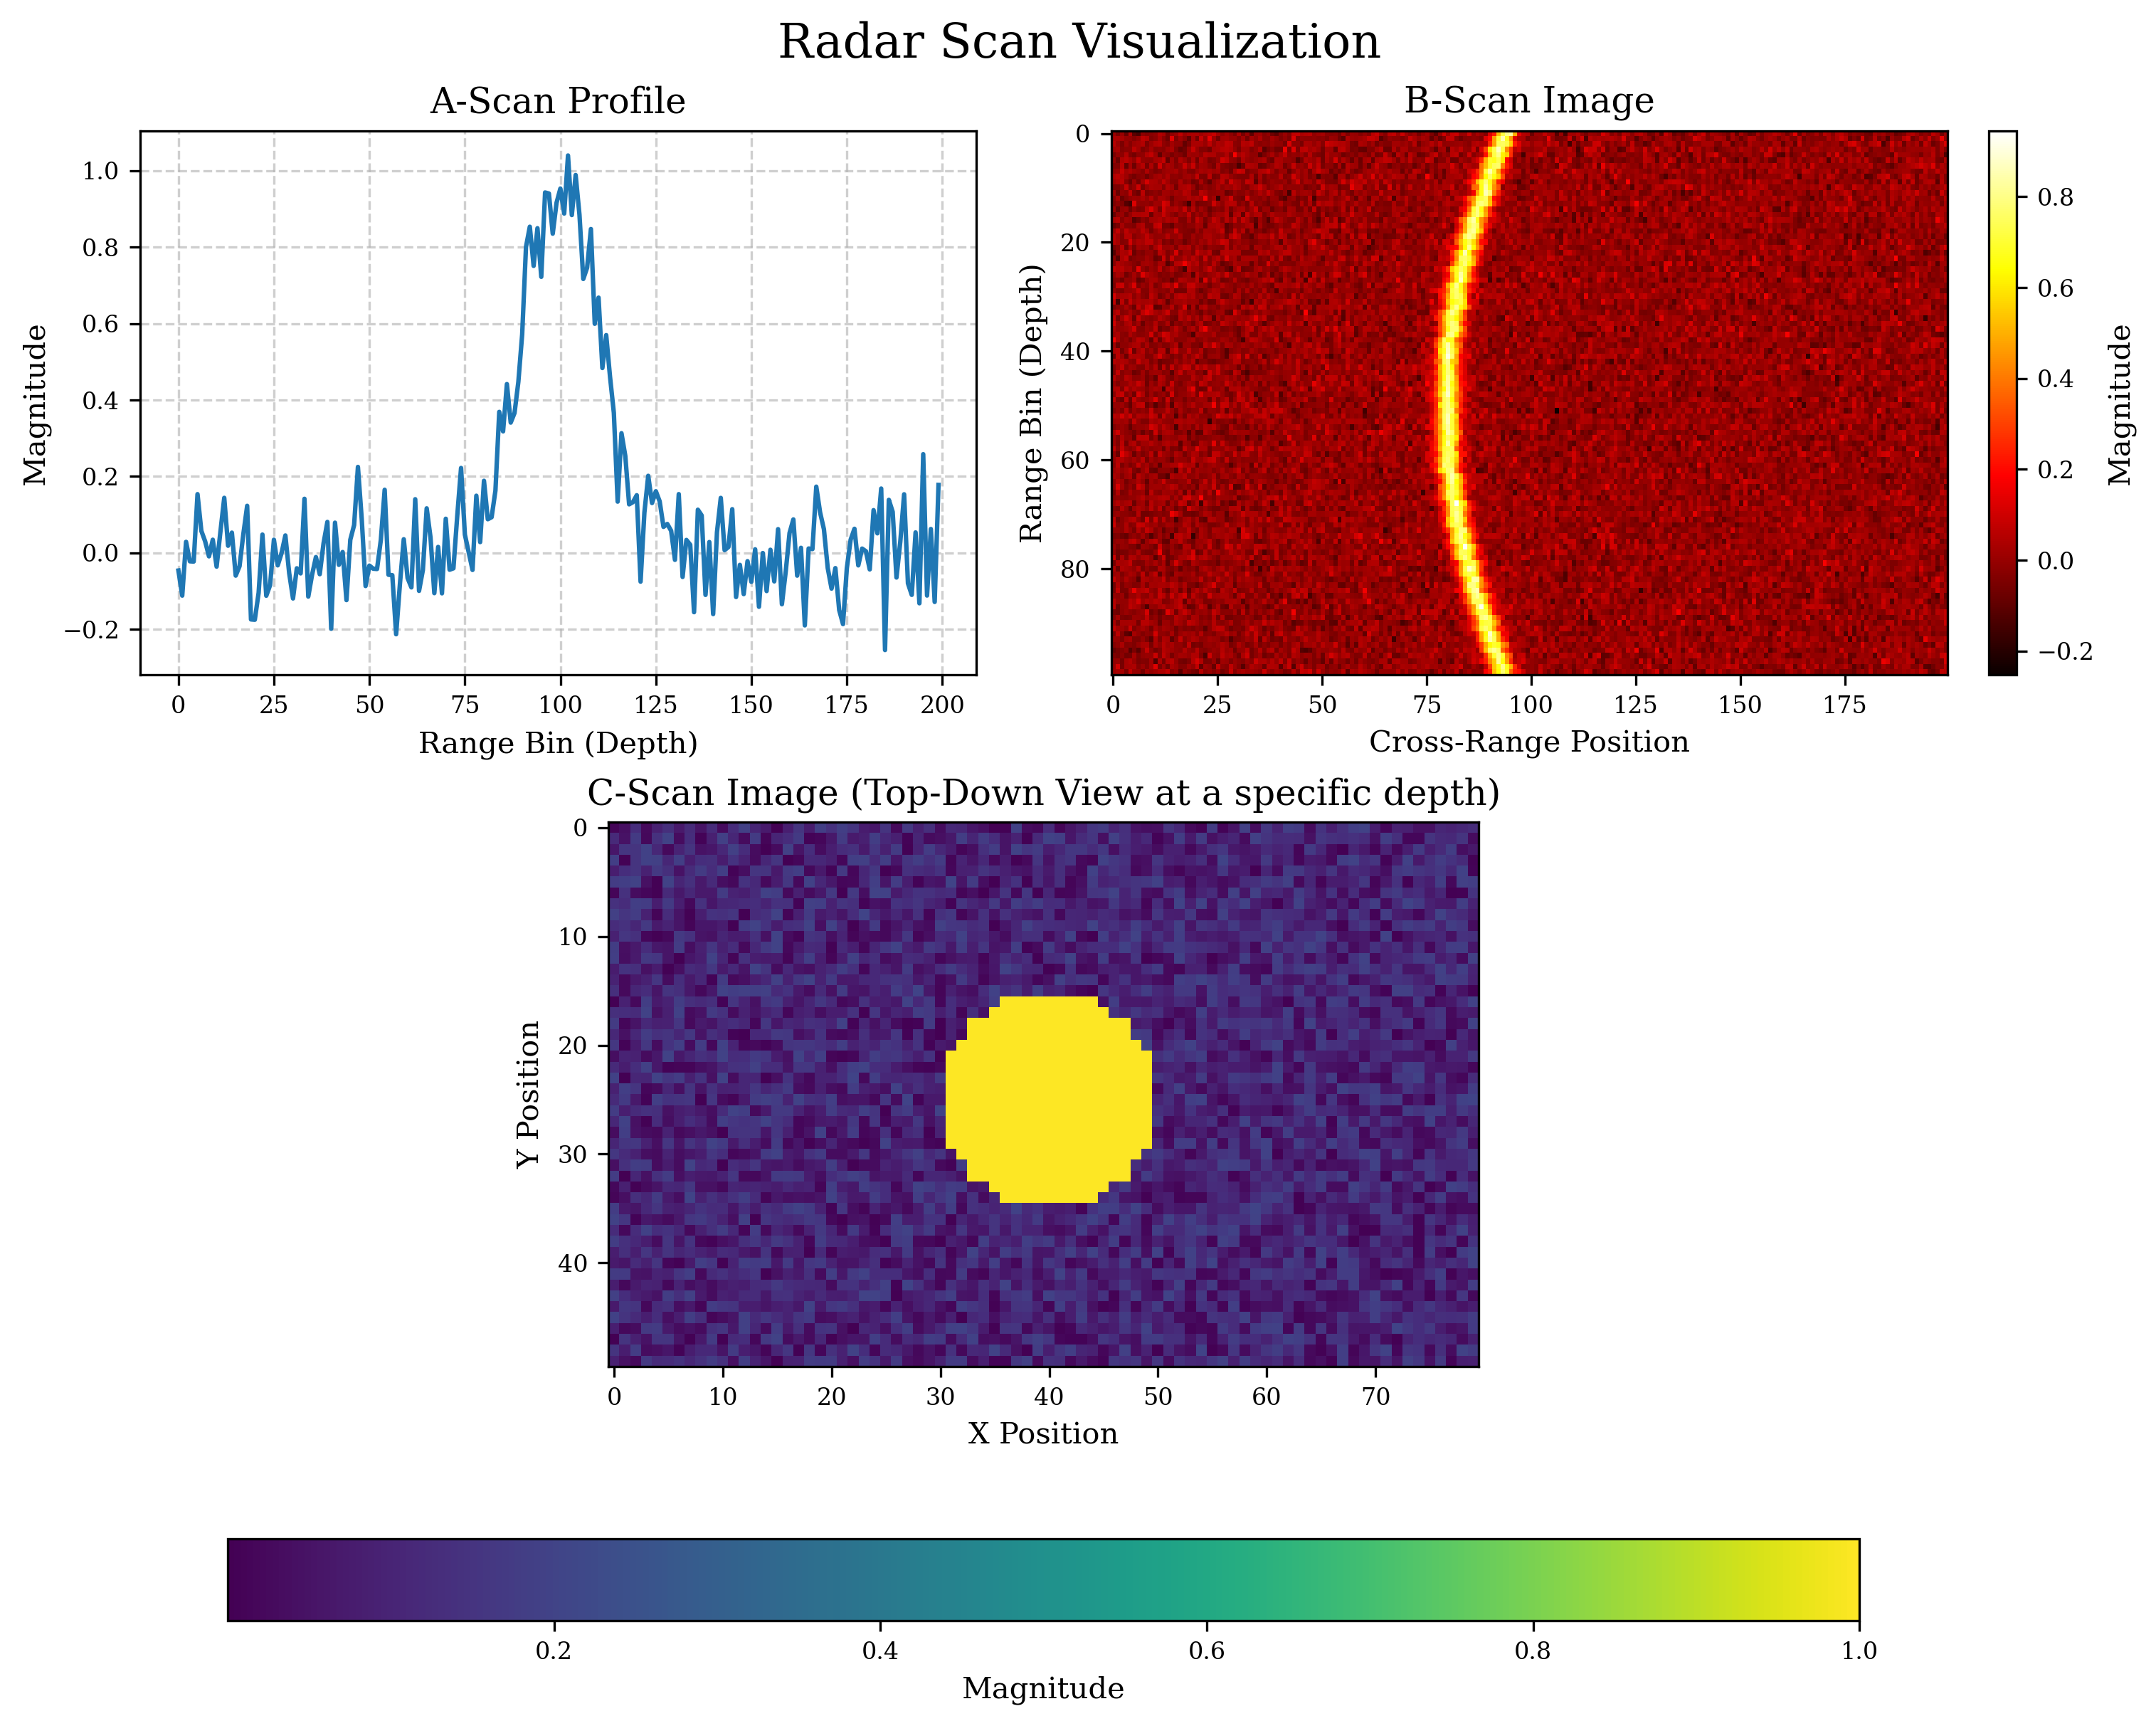

In [50]:
import numpy as np
import matplotlib.pyplot as plt

def plot_radar_scans(a_scan, b_scan, c_scan):
    """
    Plots A-scan, B-scan, and C-scan data in a single figure.

    Args:
        a_scan (np.ndarray): 1D array representing the A-scan profile.
        b_scan (np.ndarray): 2D array representing the B-scan image.
        c_scan (np.ndarray): 2D array representing the C-scan image.
    """
    # Define the layout for the subplots
    # Top row: a_scan on the left, b_scan on the right
    # Bottom row: c_scan spanning the full width
    layout = [
        ['a_scan', 'b_scan'],
        ['c_scan', 'c_scan'],
    ]

    fig, axd = plt.subplot_mosaic(layout, figsize=(10, 8), constrained_layout=True)

    # 1. Plot the A-scan (top left)
    axd['a_scan'].plot(a_scan)
    axd['a_scan'].set_title('A-Scan Profile')
    axd['a_scan'].set_xlabel('Range Bin (Depth)')
    axd['a_scan'].set_ylabel('Magnitude')
    axd['a_scan'].grid(True, linestyle='--', alpha=0.6)

    # 2. Plot the B-scan (top right)
    im_b = axd['b_scan'].imshow(np.transpose(b_scan), aspect='auto', cmap='hot', origin='upper')
    axd['b_scan'].set_title('B-Scan Image')
    axd['b_scan'].set_xlabel('Cross-Range Position')
    axd['b_scan'].set_ylabel('Range Bin (Depth)')
    fig.colorbar(im_b, ax=axd['b_scan'], label='Magnitude')

    # 3. Plot the C-scan (bottom, spanning full width)
    im_c = axd['c_scan'].imshow(c_scan, cmap='viridis', origin='upper')
    axd['c_scan'].set_title('C-Scan Image (Top-Down View at a specific depth)')
    axd['c_scan'].set_xlabel('X Position')
    axd['c_scan'].set_ylabel('Y Position')
    fig.colorbar(im_c, ax=axd['c_scan'], label='Magnitude', orientation='horizontal', pad=0.15)
    
    fig.suptitle('Radar Scan Visualization', fontsize=16)
    plt.show()

if __name__ == '__main__':
    # --- Generate Sample Data (you can replace this with your own data) ---

    # 1. Sample A-scan data (e.g., 200 range bins)
    range_bins = 200
    noise = np.random.randn(range_bins) * 0.1
    peak = np.exp(-((np.arange(range_bins) - 100)**2) / (2 * 10**2)) # Gaussian peak at bin 100
    sample_a_scan = peak + noise

    # 2. Sample B-scan data (e.g., 100 positions x 200 range bins)
    num_positions_b = 100
    sample_b_scan = np.random.randn(range_bins, num_positions_b) * 0.05
    # Add a hyperbolic shape typical of a point target in GPR
    x = np.arange(num_positions_b)
    target_depth = 80
    target_pos = 50
    hyperbola = np.sqrt(target_depth**2 + (x - target_pos)**2).astype(int)
    for i, h in enumerate(hyperbola):
        if h < range_bins:
            # CORRECTED LINE: Use [:, i] to select the entire column
            sample_b_scan[:, i] += 0.8 * np.exp(-((np.arange(range_bins) - h)**2) / 8)

    # 3. Sample C-scan data (e.g., 50x80 grid)
    sample_c_scan = np.random.rand(50, 80) * 0.2
    # Add a circular "target" in the middle
    nx, ny = sample_c_scan.shape
    x, y = np.meshgrid(np.arange(ny), np.arange(nx))
    center_x, center_y, radius = 40, 25, 10
    mask = (x - center_x)**2 + (y - center_y)**2 < radius**2
    sample_c_scan[mask] = 1.0

    # --- Call the plotting function with the sample data ---
    plot_radar_scans(sample_a_scan, sample_b_scan, sample_c_scan)

In [3]:
import os
import re
import shutil
import tempfile

def find_min_ref_files(folder_path):
    """
    Scans a folder for .dat files matching the 'scan_i_ref_j.dat' pattern
    and returns a list containing only the filename with the smallest 'j' for each 'i'.

    Args:
        folder_path (str): The full path to the directory to scan.

    Returns:
        list: A sorted list of filenames where for each scan index 'i', only the
              file with the minimum reference index 'j' is included.
        None: If the provided path is not a valid directory.
    """
    if not os.path.isdir(folder_path):
        print(f"Error: Directory not found at '{folder_path}'")
        return None

    # Regex to parse 'i' and 'j' from filenames like 'scan_i_ref_j.dat'
    # It captures the integer values for i and j.
    pattern = re.compile(r"scan_(\d+)_ref_(\d+)\.dat")
    
    # A dictionary to hold the file with the minimum 'j' for each 'i'
    # Key: i (scan index), Value: {'j': j, 'filename': filename}
    min_ref_map = {}

    # Iterate over all files in the given directory
    for filename in os.listdir(folder_path):
        match = pattern.match(filename)
        
        # Check if the filename matches our pattern
        if match:
            # Extract i and j as integers from the matched groups
            i = int(match.group(1))
            j = int(match.group(2))

            # If we haven't seen this 'i' before, or if the current 'j' is
            # smaller than the one we've stored for this 'i', we update our map.
            if i not in min_ref_map or j < min_ref_map[i]['j']:
                min_ref_map[i] = {'j': j, 'filename': filename}

    # Extract just the filenames from our map
    result_filenames = [value['filename'] for value in min_ref_map.values()]
    
    # Sort the list for a consistent and predictable order
    #result_filenames.sort()
    
    return result_filenames

# --- Demonstration ---
if __name__ == "__main__":
    # Create a temporary directory for the demonstration
    # This ensures we don't clutter your actual file system.
    temp_dir = tempfile.mkdtemp()
    print(f"Created temporary directory: {temp_dir}")

    try:
        # A list of example filenames to create
        example_files = [
            "scan_0_ref_0.dat",
            "scan_0_ref_1.dat", # Should be ignored (j=1 > j=0)
            "scan_1_ref_2.dat",
            "scan_1_ref_3.dat", # Should be ignored (j=3 > j=2)
            "scan_2_ref_4.dat",
            "scan_10_ref_9.dat",
            "scan_10_ref_5.dat", # This one should be chosen for i=10
            "other_file.txt",   # Should be ignored (doesn't match pattern)
            "scan_3_ref_0.dat",
        ]

        # Create empty files in the temporary directory
        for fname in example_files:
            with open(os.path.join(temp_dir, fname), 'w') as f:
                pass # Create an empty file
        
        print("\nFiles created in temporary directory:")
        for f in sorted(os.listdir(temp_dir)):
            print(f"- {f}")

        # Run the function on our temporary directory
        filtered_list = find_min_ref_files(temp_dir)

        print("\nFunction output (filtered list):")
        if filtered_list:
            for f in filtered_list:
                print(f"- {f}")

    finally:
        # Clean up by removing the temporary directory and its contents
        print(f"\nCleaning up and removing temporary directory: {temp_dir}")
        shutil.rmtree(temp_dir)


Created temporary directory: /tmp/tmpf5q9p3bi

Files created in temporary directory:
- other_file.txt
- scan_0_ref_0.dat
- scan_0_ref_1.dat
- scan_10_ref_5.dat
- scan_10_ref_9.dat
- scan_1_ref_2.dat
- scan_1_ref_3.dat
- scan_2_ref_4.dat
- scan_3_ref_0.dat

Function output (filtered list):
- scan_1_ref_2.dat
- scan_10_ref_5.dat
- scan_3_ref_0.dat
- scan_0_ref_0.dat
- scan_2_ref_4.dat

Cleaning up and removing temporary directory: /tmp/tmpf5q9p3bi
